# Fourier-domain single-pulsar analysis: marginalizing DM in step 1

This tutorial runs the two-step Fourier-domain likelihood of Valtolina & van Haasteren (2025, "VvH25"), with the
Gaussian-mixture (GMM) generalization, on a single pulsar, and checks it against an ordinary time-domain analysis.

**The question.** In step 1 we summarize what one pulsar's data say about its *achromatic* red-noise Fourier
coefficients $\mathbf a$, with everything else -- timing model, white noise, and here a dispersion-measure (DM)
Gaussian process with free hyperparameters -- marginalized. In step 2 we infer the red-noise spectrum $\boldsymbol\eta$
(here a power law, $\log_{10}A, \gamma$) from that summary alone. If the summary is good, the step-2 posterior on
$\boldsymbol\eta$ matches the time-domain posterior, which samples DM and red noise together.

VvH25 summarize with a single Gaussian $\mathcal N(\mathbf a\mid\hat{\mathbf a}_0,\boldsymbol\Sigma_0)$. When the
marginalized parameters (the DM hyperparameters $\boldsymbol\theta$) are covariant with the red noise, the true marginal
$\int d\boldsymbol\theta\, p(\boldsymbol\theta\mid\delta t)\,\mathcal N(\mathbf a\mid\hat{\mathbf a}(\boldsymbol\theta),\boldsymbol\Sigma(\boldsymbol\theta))$
is a *mixture* of Gaussians, and the single Gaussian can fail. J1738+0333 in EPTA DR2 is such a case: it is observed
at nearly one radio frequency, so DM and achromatic noise are hard to tell apart.

We compare three estimates of the red-noise posterior:

| | model | coefficients |
|---|---|---|
| **A** | time domain, DM + red noise sampled together (the reference) | marginalized |
| **B** | Fourier domain, Gaussian summary (VvH25) | marginalized |
| **C** | Fourier domain, GMM summary as a correction term | sampled, decentered |

C is the template for any non-Gaussian summary density -- a GMM, a normalizing flow, a heavy-tailed
distribution, ... The GMM can also be marginalized analytically; that route is shown at the end, evaluated at a few
points rather than sampled, because its cost grows with the number of mixture components.

In [1]:
import time
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro import infer
import matplotlib.pyplot as plt
import corner

import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
from discovery import fourierpta as fpta

ds.config(kernels='metamath')

## The pulsar and the models

Noise settings follow the EPTA DR2 analyses this example was first developed on: 30 achromatic red-noise and 30 DM
frequencies over the pulsar's span, and white noise fixed to the EPTA noise dictionary. The step-1 reference spectrum
$\boldsymbol\eta_0$ is deliberately loud ($\log_{10}A_0=-11.1$): step 2 divides out the reference prior
$\mathcal N(\mathbf a\mid 0,\boldsymbol\varphi_0)$, which must not constrain the coefficients more than the data do
(see VvH25, App. A).

In [2]:
datapath = Path(ds.__path__[0]) / '../../data/epta_dr2'
psr = ds.Pulsar.read_feather(datapath / 'J1738+0333.feather')

T = ds.getspan(psr)
NRN, NDM = 30, 30

eta0 = {f'{psr.name}_red_noise_log10_A': -11.1,      # step-1 reference spectrum
        f'{psr.name}_red_noise_gamma': 3.0}

priordict = {'(.*_)?dm_gp_log10_A': [-20, -11], '(.*_)?dm_gp_gamma': [0, 7],
             '(.*_)?red_noise_log10_A': [-20, -11], '(.*_)?red_noise_gamma': [0, 7]}

def run_nuts(logl, num_warmup=500, num_samples=2000, seed=0):
    model = ds_numpyro.makemodel_transformed(logl, priordict=priordict)
    sampler = ds_numpyro.makesampler_nuts(model, num_warmup=num_warmup, num_samples=num_samples)
    t = time.time()
    sampler.run(jax.random.key(seed))
    print(f'{time.time() - t:.0f} s')
    return sampler.to_df()

rn_pars = [f'{psr.name}_red_noise_log10_A', f'{psr.name}_red_noise_gamma']

The time-domain likelihood with both GPs. It serves twice: sampled with everything free it is the reference
**A**; with the red-noise spectrum held at $\boldsymbol\eta_0$ it is the step-1 likelihood.

In [3]:
psl = ds.PulsarLikelihood([psr.residuals,
                           ds.makenoise_measurement(psr, psr.noisedict),
                           ds.makegp_timing(psr, svd=True),
                           ds.makegp_fourier(psr, ds.powerlaw, NDM, T=T, fourierbasis=ds.dmfourierbasis, name='dm_gp'),
                           ds.makegp_fourier(psr, ds.powerlaw, NRN, T=T, name='red_noise')])
psl.logL.params

['J1738+0333_dm_gp_gamma',
 'J1738+0333_dm_gp_log10_A',
 'J1738+0333_red_noise_gamma',
 'J1738+0333_red_noise_log10_A']

## A. Reference: time domain

In [ ]:
chainA = run_nuts(jax.jit(psl.logL))

warmup:   0%|          | 1/2500 [00:00<14:51,  2.80it/s, 1 steps of size 2.34e+00. acc. prob=0.00]

## Step 1: summarize the red-noise coefficients

Hold the red noise at $\boldsymbol\eta_0$ and sample the DM hyperparameters $\boldsymbol\theta$ from
$p(\boldsymbol\theta\mid\delta t,\boldsymbol\eta_0)$, with all Fourier coefficients marginalized analytically.
Any sampler would do; this is just `logL` with two parameters fixed.

In [5]:
def logL_step1(params):
    return psl.logL({**params, **eta0})
logL_step1.params = [par for par in psl.logL.params if 'dm_gp' in par]

chain1 = run_nuts(jax.jit(logL_step1))


  0%|          | 0/2500 [00:00<?, ?it/s]


warmup:   0%|          | 1/2500 [00:00<11:40,  3.57it/s, 1 steps of size 2.34e+00. acc. prob=0.00]


warmup:   1%|          | 29/2500 [00:00<00:25, 96.06it/s, 31 steps of size 1.18e-01. acc. prob=0.74]


warmup:   3%|▎         | 66/2500 [00:00<00:13, 184.42it/s, 3 steps of size 5.67e-01. acc. prob=0.78]


warmup:   4%|▍         | 110/2500 [00:00<00:09, 264.27it/s, 31 steps of size 2.83e-01. acc. prob=0.78]

...


sample:  94%|█████████▍| 2349/2500 [00:04<00:00, 708.12it/s, 7 steps of size 7.01e-01. acc. prob=0.75]


sample:  97%|█████████▋| 2424/2500 [00:04<00:00, 717.09it/s, 7 steps of size 7.01e-01. acc. prob=0.74]


sample: 100%|█████████▉| 2496/2500 [00:04<00:00, 717.66it/s, 3 steps of size 7.01e-01. acc. prob=0.74]


sample: 100%|██████████| 2500/2500 [00:04<00:00, 585.53it/s, 3 steps of size 7.01e-01. acc. prob=0.74]

5 s


For each sample $\boldsymbol\theta_k$, the red-noise coefficients are Gaussian,
$\mathcal N(\mathbf a\mid\hat{\mathbf a}(\boldsymbol\theta_k),\boldsymbol\Sigma(\boldsymbol\theta_k))$ (the pulsar
likelihood's `conditional`, with the DM coefficients integrated out). `summarize_pulsar` evaluates these and combines
them by the law of total expectation and covariance (VvH25 Eq. 14):

$$\hat{\mathbf a}_0 = \mathbb E_k[\hat{\mathbf a}(\boldsymbol\theta_k)],\qquad
\boldsymbol\Sigma_0 = \mathbb E_k[\boldsymbol\Sigma(\boldsymbol\theta_k)] + \mathrm{Cov}_k[\hat{\mathbf a}(\boldsymbol\theta_k)].$$

It keeps the per-sample pairs too: they are the mixture components below. Passing arrays for some parameters is
what tells it to average; passing only scalars gives the summary at fixed noise.

In [6]:
samples = {par: chain1[par].values for par in logL_step1.params}
summary = fpta.summarize_pulsar(psr, psl, {**samples, **eta0})

summary.ahat0.shape, summary.ahat_samples.shape

((60,), (2000, 60))

## Step 2

A `FourierSummary` doubles as a *stand-in pulsar*: as a function of $\mathbf a$, the summary with the reference prior
divided out,
$\log\mathcal N(\mathbf a\mid\hat{\mathbf a}_0,\boldsymbol\Sigma_0) - \log\mathcal N(\mathbf a\mid 0,\boldsymbol\varphi_0)$,
has exactly the form of a pulsar likelihood $\log p(\delta t\mid\mathbf a)$ with

$$F^\top N^{-1}F \;\to\; \boldsymbol\Sigma_0^{-1}-\boldsymbol\varphi_0^{-1},\qquad F^\top N^{-1}\delta t \;\to\; \boldsymbol\Sigma_0^{-1}\hat{\mathbf a}_0 .$$

So step 2 uses the ordinary discovery GP and likelihood constructors; the only changes are the stand-in's data
(`summary.residuals`, unit white noise from `makenoise_summary`) and `fourierbasis=fpta.summarybasis` on its GPs.
(The same works for whole arrays, with `makecommongp_fourier` / `makeglobalgp_fourier` -- including HD.)

### B. Gaussian summary (VvH25)

In [7]:
rn = ds.makegp_fourier(summary, ds.powerlaw, NRN, T=T, fourierbasis=fpta.summarybasis, name='red_noise')
pslB = ds.PulsarLikelihood([summary.residuals, fpta.makenoise_summary(summary), rn])

chainB = run_nuts(jax.jit(pslB.logL))


  0%|          | 0/2500 [00:00<?, ?it/s]


warmup:   0%|          | 1/2500 [00:00<11:33,  3.60it/s, 3 steps of size 2.34e+00. acc. prob=0.00]


warmup:   1%|          | 21/2500 [00:00<00:35, 70.02it/s, 15 steps of size 1.74e-02. acc. prob=0.70]


warmup:   2%|▏         | 56/2500 [00:00<00:15, 160.37it/s, 9 steps of size 2.34e-02. acc. prob=0.75]


warmup:   4%|▍         | 110/2500 [00:00<00:08, 278.26it/s, 13 steps of size 6.62e-01. acc. prob=0.78]

...


sample:  90%|█████████ | 2251/2500 [00:03<00:00, 798.44it/s, 7 steps of size 3.91e-01. acc. prob=0.93] 


sample:  93%|█████████▎| 2335/2500 [00:03<00:00, 808.88it/s, 7 steps of size 3.91e-01. acc. prob=0.93]


sample:  97%|█████████▋| 2423/2500 [00:03<00:00, 828.70it/s, 9 steps of size 3.91e-01. acc. prob=0.93]


sample: 100%|██████████| 2500/2500 [00:03<00:00, 686.33it/s, 3 steps of size 3.91e-01. acc. prob=0.93]

4 s


### C. GMM summary as a correction, coefficients sampled

The general route, for any non-Gaussian summary density. Write the density $q$ in whitened coordinates
$\mathbf y = \mathbf L_0^{-1}(\mathbf a-\hat{\mathbf a}_0)$, $\mathbf L_0 = \mathrm{chol}(\boldsymbol\Sigma_0)$, where the
Gaussian summary is $\mathcal N(\mathbf y\mid 0,\mathbf I)$. Step 2 then gains a per-pulsar correction (Eq. 28, 34)

$$\log w(\mathbf a) = \log q(\mathbf y) - \log\mathcal N(\mathbf y\mid 0,\mathbf I)$$

on top of the Gaussian-summary likelihood. It cannot be integrated out, so the coefficients are sampled, with the
CURN-style decentering of `ArrayLikelihood(..., decenter=True)` to avoid Neal's funnel.

The density goes on the summary (`summary.density`, anything with a `log_prob(y)` method: `summary.mixture(K)`, or a
trained `flowjax` flow), and `makecorrection(summary)` turns it into a term of the stand-in's `PulsarLikelihood`. The
pulsar's `clogL`, and the `clogL` of any `ArrayLikelihood` containing it, add the term at the sampled coefficients.

The mixture is that of the step-1 conditionals (paper Eq. 19, A8),
$q(\mathbf a) = \frac1K\sum_k\mathcal N(\mathbf a\mid\hat{\mathbf a}(\boldsymbol\theta_k),\boldsymbol\Sigma(\boldsymbol\theta_k))$,
with $K$ samples spaced evenly through the step-1 chain. **$K$ matters**: the non-Gaussian tails are carried by a few
rare components, and for this pulsar $K=64$ still gives (wrongly) the Gaussian answer while $K=512$ matches the time
domain. The prior swap is importance sampling from the reference spectrum $\boldsymbol\varphi_0$ to $\boldsymbol\varphi(\boldsymbol\eta)$,
so a loud $\boldsymbol\eta_0$ is always valid but needs more components.

In [8]:
K = 512
summary.density = summary.mixture(K)

# the step-2 red-noise prior, as a GP on the stand-in pulsar
irn = ds.makecommongp_fourier([summary], ds.powerlaw, NRN, T, fourierbasis=fpta.summarybasis, name='red_noise')

pslC = ds.PulsarLikelihood([summary.residuals, fpta.makenoise_summary(summary), fpta.makecorrection(summary)])
likeC = ds.ArrayLikelihood([pslC], commongp=irn, decenter=True)

clogL = jax.jit(likeC.clogL)
cname = f'{psr.name}_red_noise_coefficients({2*NRN})'
likeC.clogL.params

['J1738+0333_red_noise_coefficients(60)',
 'J1738+0333_red_noise_gamma',
 'J1738+0333_red_noise_log10_A']

With decentering, the coefficient parameter is the whitened $\boldsymbol\xi$, and `clogL` returns the log-density
together with the physical coefficients $\mathbf a(\boldsymbol\xi,\boldsymbol\eta)$. The log-density already includes the
coefficient prior and the Jacobian, so $\boldsymbol\xi$ gets a flat prior (the standard-normal draw below is undone by the
$+\tfrac12\boldsymbol\xi^\top\boldsymbol\xi$).

In [9]:
def modelC():
    params = {par: numpyro.sample(par, dist.Uniform(*ds.prior.getprior_uniform(par, priordict))) for par in rn_pars}
    xi = numpyro.sample('xi', dist.Normal(0, 1).expand([2*NRN]))

    logp, c = clogL({**params, cname: xi})
    numpyro.deterministic('a', c[0])
    numpyro.factor('logL', logp + 0.5 * xi @ xi)

mcmc = infer.MCMC(infer.NUTS(modelC, max_tree_depth=10), num_warmup=1000, num_samples=4000)
t = time.time()
mcmc.run(jax.random.key(1))
print(f'{time.time() - t:.0f} s')
chainC = {par: np.asarray(v) for par, v in mcmc.get_samples().items() if par in rn_pars}


  0%|          | 0/5000 [00:00<?, ?it/s]


warmup:   0%|          | 1/5000 [00:00<41:06,  2.03it/s, 3 steps of size 4.87e+00. acc. prob=0.40]


warmup:   0%|          | 14/5000 [00:00<02:43, 30.51it/s, 31 steps of size 2.50e-01. acc. prob=0.72]


warmup:   0%|          | 22/5000 [00:00<01:57, 42.42it/s, 15 steps of size 3.97e-01. acc. prob=0.75]


warmup:   1%|          | 30/5000 [00:00<01:55, 43.09it/s, 15 steps of size 3.30e-01. acc. prob=0.76]

...


sample: 100%|█████████▉| 4996/5000 [04:53<00:00, 16.46it/s, 63 steps of size 4.58e-02. acc. prob=0.98] 


sample: 100%|█████████▉| 4998/5000 [04:53<00:00, 16.74it/s, 127 steps of size 4.58e-02. acc. prob=0.98]


sample: 100%|██████████| 5000/5000 [04:53<00:00, 15.47it/s, 127 steps of size 4.58e-02. acc. prob=0.98]


sample: 100%|██████████| 5000/5000 [04:53<00:00, 17.02it/s, 127 steps of size 4.58e-02. acc. prob=0.98]

295 s


## Comparison

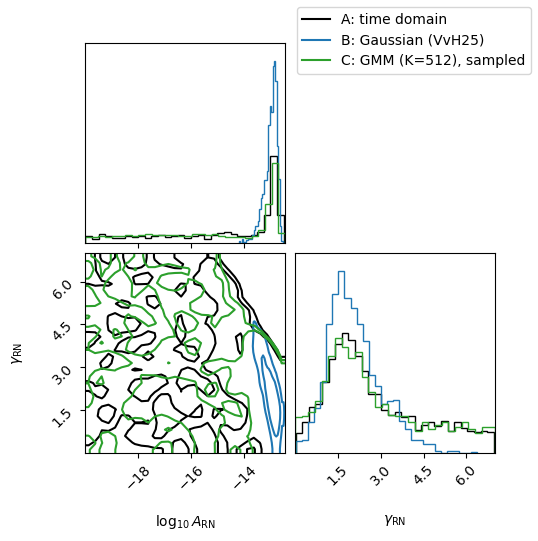

A: time domain             log10_A -14.879 ± 2.293    gamma  2.76 ± 1.69
B: Gaussian (VvH25)        log10_A -12.983 ± 0.245    gamma  2.09 ± 0.92
C: GMM (K=512), sampled    log10_A -15.106 ± 2.345    gamma  2.75 ± 1.77


In [10]:
chains = {'A: time domain': chainA, 'B: Gaussian (VvH25)': chainB, f'C: GMM (K={K}), sampled': chainC}
colors = ['k', 'C0', 'C2']

fig = None
for (label, chain), color in zip(chains.items(), colors):
    x = np.column_stack([np.asarray(chain[par]) for par in rn_pars])
    fig = corner.corner(x, fig=fig, color=color, bins=30, smooth=1.0, plot_datapoints=False, plot_density=False,
                        levels=(0.68, 0.95), labels=[r'$\log_{10}A_\mathrm{RN}$', r'$\gamma_\mathrm{RN}$'],
                        hist_kwargs=dict(density=True))
fig.legend([plt.Line2D([], [], color=c) for c in colors], chains.keys(), loc='upper right')
plt.show()

for label, chain in chains.items():
    a, g = (np.asarray(chain[par]) for par in rn_pars)
    print(f'{label:26s} log10_A {a.mean():7.3f} ± {a.std():.3f}    gamma {g.mean():5.2f} ± {g.std():.2f}')

The time domain (A) gives only an upper limit on achromatic red noise ($\log_{10}A \lesssim -12.7$ at 95%), while
the Gaussian summary (B) reports a confident detection at $\log_{10}A\approx-13.0\pm0.25$. With single-frequency data the
excess power can be DM or red noise, and the time-domain posterior keeps both options. The step-1 conditionals know
this -- samples with loud DM leave little power in the red-noise coefficients -- but averaging them into one Gaussian
loses it. The GMM of those same conditionals (C) recovers the time-domain posterior.

## Aside: the GMM marginalized analytically

Each mixture component's integral over $\mathbf a$ against the prior swap is a Gaussian integral, so the GMM can
also be marginalized analytically (paper Eq. 21): the likelihood is a log-sum-exp over components of their evidences.
This factorizes over pulsars only when the prior does not correlate them, so `mixture_logL` takes the red-noise prior
as a common GP (SPNA, IRN, CURN; not HD). It is the same model as C with the coefficients integrated out, so its
log-likelihood differences should track C's posterior; each call costs one $2N_\mathrm{RN}\times2N_\mathrm{RN}$ Cholesky
factorization per component.

In [11]:
logL_gmm = jax.jit(fpta.mixture_logL([summary], irn, K=K))
logL_gauss = jax.jit(pslB.logL)

for A in [-17.0, -15.0, -13.0, -12.5]:
    p = {rn_pars[0]: A, rn_pars[1]: 3.0}
    print(f'log10_A = {A:6.1f}:  GMM {float(logL_gmm(p)):10.3f}   Gaussian {float(logL_gauss(p)):10.3f}')

t = time.time(); jax.block_until_ready(logL_gmm(p)); print(f'{(time.time() - t) * 1e3:.0f} ms per call at K = {K}')

log10_A =  -17.0:  GMM    129.456   Gaussian    -59.878
log10_A =  -15.0:  GMM    129.456   Gaussian    -59.843


log10_A =  -13.0:  GMM    131.779   Gaussian    -48.118
log10_A =  -12.5:  GMM    121.572   Gaussian    -58.770
11 ms per call at K = 512


The two are defined up to different constants, so compare *differences* between rows: the Gaussian summary
prefers $\log_{10}A\approx-13$ by many units over quiet red noise, the GMM much less so -- the same difference seen
in the posteriors above.

## Things to try

- **Other noise models in step 1.** Anything in the step-1 `PulsarLikelihood` that is not the `red_noise` GP gets
  marginalized: a free chromatic index (`fourierbasis=ds.dmfourierbasis_alpha`), a scattering GP
  (`ds.make_dmfourierbasis(alpha=4.0)`), solar-wind DM, free white noise (`makenoise_measurement(psr)` without a noise
  dictionary, and its parameters sampled in step 1 alongside the others). Step 2 is unchanged.
- **The number of components $K$.** How many does it take for C to agree with A? Compare $K=64$ and $K=512$, and
  check how the answer depends on the reference spectrum $\boldsymbol\eta_0$.
- **A normalizing flow.** Train a `flowjax` distribution on the whitened step-1 coefficient draws
  $\mathbf y = \mathbf L_0^{-1}(\mathbf a-\hat{\mathbf a}_0)$, set `summary.density = flow`, and rerun C unchanged.
- **The reference spectrum $\boldsymbol\eta_0$.** Making it too quiet should break things: the stand-in construction
  raises an error when $\boldsymbol\Sigma_0^{-1}-\boldsymbol\varphi_0^{-1}$ stops being positive semi-definite.